# Classical random-imagery model comparison

## tl;dr

- **No classical variant shows a robust balanced-accuracy gain over Logistic Regression.**
  Cross-subject estimates span roughly 0.493-0.518 and combined within-subject estimates
  0.487-0.503; every pointwise paired 95% subject-bootstrap interval versus Logistic includes
  zero.
- The best descriptive cross-subject balanced accuracy is shared by independent Ridge Regression
  (0.518) and independent Random Forest (0.518). The best combined within-subject estimate is
  multi-output ElasticNet/Lasso (0.503). These are rankings, not evidence of superiority.
- Grouped Platt calibration sharply reduces pooled classifier ECE relative to native Logistic
  scores, but does not improve thresholded reconstruction accuracy.
- The global-majority non-EEG baseline has lower score-MSE than every learned model in both
  protocols. Exact 36-pixel reconstruction accuracy is zero for every model.

The protocols remain separate throughout: cross-subject tests unseen identities, while the
bidirectional cross-trial result tests new trials from overlapping identities and combines both
directions only after confirming disjoint sample keys.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from experiments.random_imagery import (
    PLANNED_MODEL_IDS,
    compare_protocol_models,
    load_model_run,
)

sns.set_theme(style="whitegrid", context="notebook")
MODEL_ROOT = Path("../artifacts/experiments/random-imagery")
REFERENCE_ROOT = Path("../artifacts/experiments/logistic-regression")
REFERENCE_RUN_DIRS = {
    "cross-subject": (REFERENCE_ROOT / "4fcdf3c4fa5ef75a",),
    "within-subject": (
        REFERENCE_ROOT / "ea7f8aa10a39cea0",
        REFERENCE_ROOT / "0ab4cb2a7512ab19",
    ),
}
PROTOCOL_LABELS = {
    "cross-subject": "Cross-subject",
    "within-subject": "Combined bidirectional cross-trial",
}
N_RESAMPLES = 2_000
RANDOM_STATE = 42

## Context & Methods

All results come from the immutable artifacts produced in notebook 5.2 and the existing
schema-v2 Logistic Regression reference. Each schema-v3 run is loaded through the safe reader;
joblib pipelines are not deserialized.

For each protocol, the comparison code requires every model to have the same ordered test sample
keys, targets, and subject IDs as Logistic Regression. The within-subject estimate concatenates
Trial 1 -> Trial 2 and Trial 2 -> Trial 1, giving six rows per subject while preserving subject
clusters.

Uncertainty uses the same 2,000 subject-cluster bootstrap draws for every model. Paired
improvement is defined so positive is always better: model minus Logistic for balanced accuracy
and IoU, Logistic minus model for score-MSE and Hamming loss. Intervals are pointwise 95% intervals
and are not multiplicity-adjusted.

Classifier scores are probabilities: native for Logistic and grouped train-only Platt-calibrated
for Linear SVM and Ridge Classifier. Regressor scores are clipped continuous outputs, not
probabilities. Their calibration is therefore not assessed; lower/upper clipping fractions are
reported instead. Pooled ECE treats each sample-pixel pair as an observation and is descriptive,
not a spatially independent inferential statistic.

In [2]:
def discover_model_run_dirs(protocol: str) -> dict[str, tuple[Path, ...]]:
    expected_directions = (
        ("cross-subject",)
        if protocol == "cross-subject"
        else ("trial-1-to-trial-2", "trial-2-to-trial-1")
    )
    result = {}
    for model_id in PLANNED_MODEL_IDS:
        by_direction = {}
        for run_dir in sorted((MODEL_ROOT / model_id).iterdir()):
            run = load_model_run(run_dir)
            if run.evaluation["protocol"] == protocol:
                direction = run.evaluation["direction"]["name"]
                if direction in by_direction:
                    raise ValueError(f"Duplicate {model_id} direction: {direction}")
                by_direction[direction] = run_dir
        if set(by_direction) != set(expected_directions):
            raise ValueError(
                f"{model_id} has {tuple(by_direction)}; expected {expected_directions}"
            )
        result[model_id] = tuple(
            by_direction[direction] for direction in expected_directions
        )
    return result


comparisons = {
    protocol: compare_protocol_models(
        protocol,
        reference_run_dirs=REFERENCE_RUN_DIRS[protocol],
        model_run_dirs=discover_model_run_dirs(protocol),
        n_resamples=N_RESAMPLES,
        random_state=RANDOM_STATE,
        calibration_bins=10,
    )
    for protocol in ("cross-subject", "within-subject")
}

assert comparisons["cross-subject"].n_test_rows == 39
assert comparisons["cross-subject"].n_subjects == 7
assert comparisons["within-subject"].n_test_rows == 162
assert comparisons["within-subject"].n_subjects == 27
assert all(comparison.n_resamples == 2_000 for comparison in comparisons.values())
{
    protocol: {
        "test_rows": comparison.n_test_rows,
        "subjects": comparison.n_subjects,
        "accepted_bootstraps": comparison.n_resamples,
        "draw_attempts": comparison.n_attempts,
    }
    for protocol, comparison in comparisons.items()
}

{'cross-subject': {'test_rows': 39,
  'subjects': 7,
  'accepted_bootstraps': 2000,
  'draw_attempts': 2002},
 'within-subject': {'test_rows': 162,
  'subjects': 27,
  'accepted_bootstraps': 2000,
  'draw_attempts': 2000}}

## Data

The tables below retain protocol, task, topology, score semantics, selected feature family, and
all primary reconstruction metrics. `score_mse` is Brier score for classifier probabilities and
clipped MSE for regressors; those semantics must remain visible when comparing values.

In [3]:
model_rows = []
paired_rows = []
calibration_rows = []
clipping_rows = []
baseline_rows = []

for protocol, comparison in comparisons.items():
    protocol_label = PROTOCOL_LABELS[protocol]
    for model in comparison.models:
        model_rows.append(
            {
                "protocol": protocol_label,
                "model_id": model.model_id,
                "model": model.label,
                "task": model.task,
                "topology": model.topology,
                "score_semantics": model.score_semantics,
                "features": " | ".join("+".join(parts) for parts in model.selected_feature_families),
                "balanced_accuracy": model.metrics.mean_balanced_accuracy,
                "ba_ci_low": model.balanced_accuracy_lower,
                "ba_ci_high": model.balanced_accuracy_upper,
                "score_mse": model.metrics.mean_score_mse,
                "sample_iou": model.metrics.mean_sample_iou,
                "hamming_loss": model.metrics.hamming_loss,
                "exact_match": model.metrics.exact_match_accuracy,
            }
        )
        for paired in model.paired_differences:
            paired_rows.append(
                {
                    "protocol": protocol_label,
                    "model_id": model.model_id,
                    "model": model.label,
                    "metric": paired.metric,
                    "improvement": paired.improvement,
                    "ci_low": paired.lower,
                    "ci_high": paired.upper,
                }
            )
        if model.calibration_ece is not None:
            calibration_rows.append(
                {
                    "protocol": protocol_label,
                    "model_id": model.model_id,
                    "model": model.label,
                    "ece": model.calibration_ece,
                    "score_mse": model.metrics.mean_score_mse,
                }
            )
        if model.clipping_below_zero_fraction is not None:
            clipping_rows.append(
                {
                    "protocol": protocol_label,
                    "model_id": model.model_id,
                    "model": model.label,
                    "below_zero": model.clipping_below_zero_fraction,
                    "above_one": model.clipping_above_one_fraction,
                    "total_clipped": (
                        model.clipping_below_zero_fraction
                        + model.clipping_above_one_fraction
                    ),
                }
            )
    for baseline in comparison.baselines:
        baseline_rows.append(
            {
                "protocol": protocol_label,
                "baseline": baseline.name,
                "balanced_accuracy": baseline.metrics.mean_balanced_accuracy,
                "score_mse": baseline.metrics.mean_score_mse,
                "sample_iou": baseline.metrics.mean_sample_iou,
                "hamming_loss": baseline.metrics.hamming_loss,
            }
        )

models_df = pd.DataFrame(model_rows)
paired_df = pd.DataFrame(paired_rows)
calibration_df = pd.DataFrame(calibration_rows)
clipping_df = pd.DataFrame(clipping_rows)
baselines_df = pd.DataFrame(baseline_rows)

for protocol_label in PROTOCOL_LABELS.values():
    print(protocol_label)
    display(
        models_df.loc[models_df["protocol"] == protocol_label]
        .drop(columns=["protocol", "model_id"])
        .sort_values("balanced_accuracy", ascending=False)
        .style.format(
            {
                "balanced_accuracy": "{:.3f}",
                "ba_ci_low": "{:.3f}",
                "ba_ci_high": "{:.3f}",
                "score_mse": "{:.3f}",
                "sample_iou": "{:.3f}",
                "hamming_loss": "{:.3f}",
                "exact_match": "{:.3f}",
            }
        )
    )

Cross-subject


,model,task,topology,score_semantics,features,balanced_accuracy,ba_ci_low,ba_ci_high,score_mse,sample_iou,hamming_loss,exact_match
3,Ridge Regression (independent),regressor,independent,clipped_regression,lgp,0.518,0.487,0.562,0.332,0.327,0.481,0.000
7,Random Forest Regressor (independent),regressor,independent,clipped_regression,lbp,0.518,0.503,0.531,0.265,0.329,0.476,0.000
5,ElasticNet/Lasso (independent),regressor,independent,clipped_regression,lbp,0.512,0.491,0.531,0.301,0.325,0.483,0.000
0,Logistic Regression,classifier,independent,native_probability,lbp,0.510,0.496,0.521,0.334,0.335,0.486,0.000
6,ElasticNet/Lasso (multi-output),regressor,multioutput,clipped_regression,time+spectral,0.506,0.479,0.529,0.339,0.337,0.486,0.000
8,Random Forest Regressor (multi-output),regressor,multioutput,clipped_regression,time,0.504,0.479,0.527,0.255,0.312,0.486,0.000
2,Ridge Classifier,classifier,independent,calibrated_probability,lgp,0.502,0.488,0.524,0.253,0.312,0.484,0.000
9,PLS Regression (multi-output),regressor,multioutput,clipped_regression,correlation,0.498,0.481,0.516,0.262,0.300,0.489,0.000
4,Ridge Regression (multi-output),regressor,multioutput,clipped_regression,time+spectral,0.498,0.473,0.521,0.339,0.327,0.496,0.000
1,Linear SVM,classifier,independent,calibrated_probability,lbp,0.493,0.461,0.526,0.254,0.291,0.496,0.000


Combined bidirectional cross-trial


,model,task,topology,score_semantics,features,balanced_accuracy,ba_ci_low,ba_ci_high,score_mse,sample_iou,hamming_loss,exact_match
16,ElasticNet/Lasso (multi-output),regressor,multioutput,clipped_regression,spectral | time+spectral,0.503,0.490,0.516,0.361,0.325,0.493,0.000
10,Logistic Regression,classifier,independent,native_probability,correlation | time+spectral,0.500,0.486,0.511,0.364,0.336,0.496,0.000
17,Random Forest Regressor (independent),regressor,independent,clipped_regression,spectral | time+spectral,0.499,0.486,0.511,0.284,0.325,0.494,0.000
13,Ridge Regression (independent),regressor,independent,clipped_regression,log_covariance | time+spectral,0.496,0.482,0.510,0.383,0.325,0.500,0.000
15,ElasticNet/Lasso (independent),regressor,independent,clipped_regression,spectral | lbp,0.496,0.482,0.507,0.333,0.317,0.496,0.000
18,Random Forest Regressor (multi-output),regressor,multioutput,clipped_regression,spectral | lndp,0.496,0.481,0.510,0.271,0.317,0.495,0.000
14,Ridge Regression (multi-output),regressor,multioutput,clipped_regression,time | spectral,0.495,0.482,0.506,0.298,0.321,0.498,0.000
19,PLS Regression (multi-output),regressor,multioutput,clipped_regression,spectral | correlation,0.494,0.480,0.506,0.278,0.308,0.496,0.000
12,Ridge Classifier,classifier,independent,calibrated_probability,log_covariance | time+spectral,0.487,0.477,0.497,0.257,0.300,0.494,0.000
11,Linear SVM,classifier,independent,calibrated_probability,lbp | time+spectral,0.487,0.476,0.497,0.260,0.303,0.495,0.000


In [4]:
print("Non-EEG baselines")
display(
    baselines_df.sort_values(["protocol", "baseline"]).style.format(
        {
            "balanced_accuracy": "{:.3f}",
            "score_mse": "{:.3f}",
            "sample_iou": "{:.3f}",
            "hamming_loss": "{:.3f}",
        }
    )
)

print("Classifier calibration diagnostics (pooled sample-pixel ECE)")
display(
    calibration_df.sort_values(["protocol", "ece"]).style.format(
        {"ece": "{:.3f}", "score_mse": "{:.3f}"}
    )
)

print("Regression clipping diagnostics")
display(
    clipping_df.sort_values(["protocol", "total_clipped"], ascending=[True, False])
    .style.format(
        {
            "below_zero": "{:.1%}",
            "above_one": "{:.1%}",
            "total_clipped": "{:.1%}",
        }
    )
)

Non-EEG baselines


,protocol,baseline,balanced_accuracy,score_mse,sample_iou,hamming_loss
3,Combined bidirectional cross-trial,global_majority,0.500,0.250,0.000,0.488
4,Combined bidirectional cross-trial,pixel_frequency,0.474,0.255,0.282,0.502
5,Combined bidirectional cross-trial,seeded_bernoulli,0.502,0.255,0.328,0.495
0,Cross-subject,global_majority,0.500,0.250,0.000,0.479
1,Cross-subject,pixel_frequency,0.500,0.251,0.294,0.476
2,Cross-subject,seeded_bernoulli,0.500,0.251,0.326,0.497


Classifier calibration diagnostics (pooled sample-pixel ECE)


,protocol,model_id,model,ece,score_mse
5,Combined bidirectional cross-trial,ridge-classifier-independent,Ridge Classifier,0.056,0.257
4,Combined bidirectional cross-trial,linear-svm-independent,Linear SVM,0.065,0.260
3,Combined bidirectional cross-trial,logistic-regression-independent,Logistic Regression,0.279,0.364
2,Cross-subject,ridge-classifier-independent,Ridge Classifier,0.032,0.253
1,Cross-subject,linear-svm-independent,Linear SVM,0.052,0.254
0,Cross-subject,logistic-regression-independent,Logistic Regression,0.248,0.334


Regression clipping diagnostics


,protocol,model_id,model,below_zero,above_one,total_clipped
7,Combined bidirectional cross-trial,ridge-regression-independent,Ridge Regression (independent),18.0%,16.9%,34.9%
10,Combined bidirectional cross-trial,elastic-net-multioutput,ElasticNet/Lasso (multi-output),15.5%,14.0%,29.6%
9,Combined bidirectional cross-trial,elastic-net-independent,ElasticNet/Lasso (independent),9.6%,8.3%,17.9%
8,Combined bidirectional cross-trial,ridge-regression-multioutput,Ridge Regression (multi-output),4.1%,4.1%,8.2%
13,Combined bidirectional cross-trial,pls-regression-multioutput,PLS Regression (multi-output),1.2%,0.7%,2.0%
11,Combined bidirectional cross-trial,random-forest-independent,Random Forest Regressor (independent),0.0%,0.0%,0.0%
12,Combined bidirectional cross-trial,random-forest-multioutput,Random Forest Regressor (multi-output),0.0%,0.0%,0.0%
3,Cross-subject,elastic-net-multioutput,ElasticNet/Lasso (multi-output),11.0%,11.0%,22.0%
1,Cross-subject,ridge-regression-multioutput,Ridge Regression (multi-output),10.8%,10.4%,21.2%
0,Cross-subject,ridge-regression-independent,Ridge Regression (independent),9.3%,8.0%,17.4%


## Results

The first figure shows absolute balanced accuracy and its subject-bootstrap interval. The 0.5
line is the balanced-accuracy chance benchmark. Absolute intervals describe each model; the next
figure is the more relevant paired comparison because all models share identical test rows.

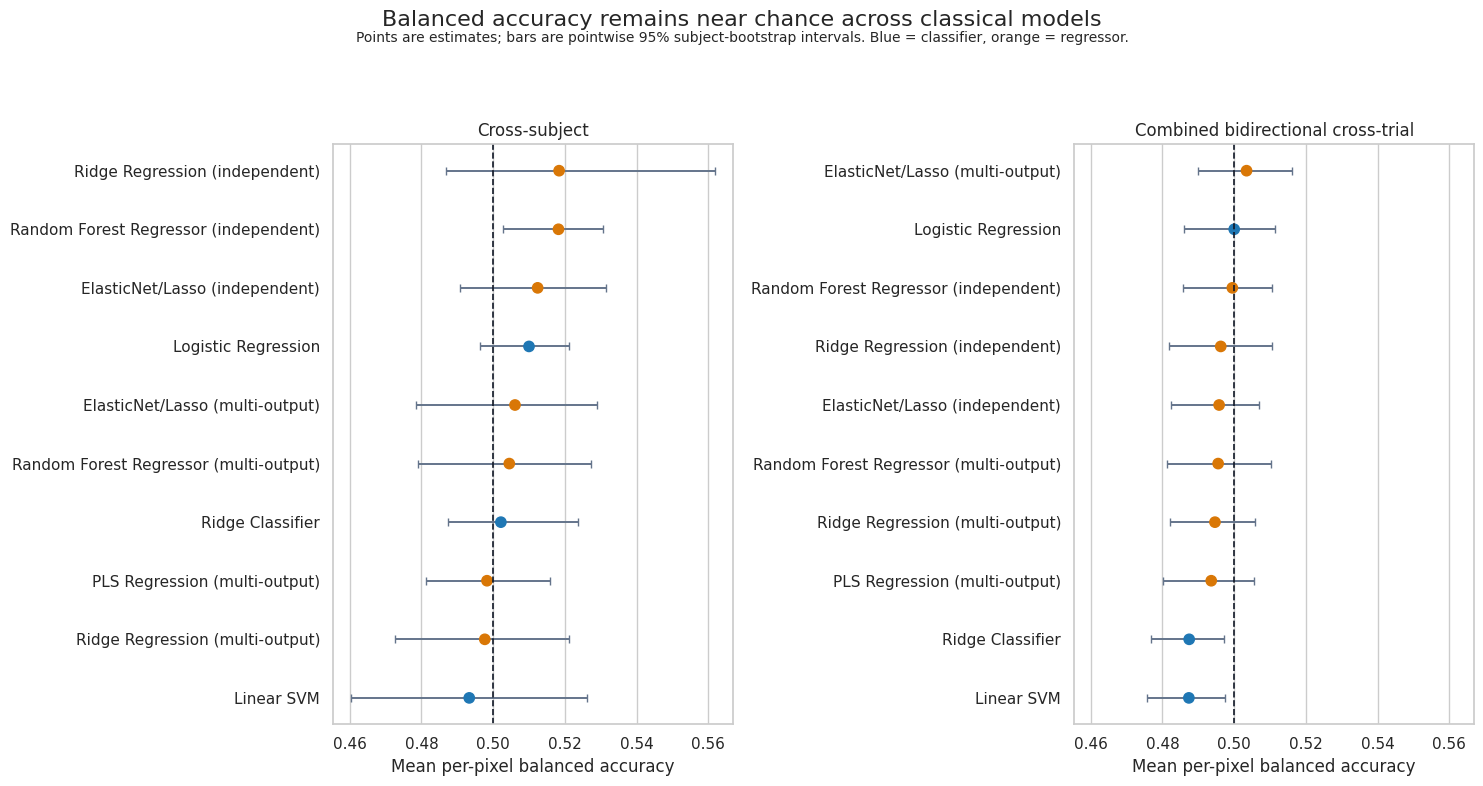

In [5]:
task_palette = {"classifier": "#1f77b4", "regressor": "#d97706"}
fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharex=True)
for ax, protocol_label in zip(axes, PROTOCOL_LABELS.values(), strict=True):
    frame = (
        models_df.loc[models_df["protocol"] == protocol_label]
        .sort_values("balanced_accuracy")
        .reset_index(drop=True)
    )
    y = np.arange(len(frame))
    colors = frame["task"].map(task_palette)
    ax.errorbar(
        frame["balanced_accuracy"],
        y,
        xerr=np.vstack(
            [
                frame["balanced_accuracy"] - frame["ba_ci_low"],
                frame["ba_ci_high"] - frame["balanced_accuracy"],
            ]
        ),
        fmt="none",
        ecolor="#64748b",
        elinewidth=1.4,
        capsize=3,
        zorder=1,
    )
    ax.scatter(frame["balanced_accuracy"], y, c=colors, s=55, zorder=2)
    ax.axvline(0.5, color="#111827", linestyle="--", linewidth=1.2)
    ax.set_yticks(y, frame["model"])
    ax.set_title(protocol_label)
    ax.set_xlabel("Mean per-pixel balanced accuracy")
    ax.grid(axis="y", visible=False)
fig.suptitle("Balanced accuracy remains near chance across classical models", fontsize=16)
fig.text(
    0.5,
    0.94,
    "Points are estimates; bars are pointwise 95% subject-bootstrap intervals. "
    "Blue = classifier, orange = regressor.",
    ha="center",
    fontsize=10,
)
fig.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

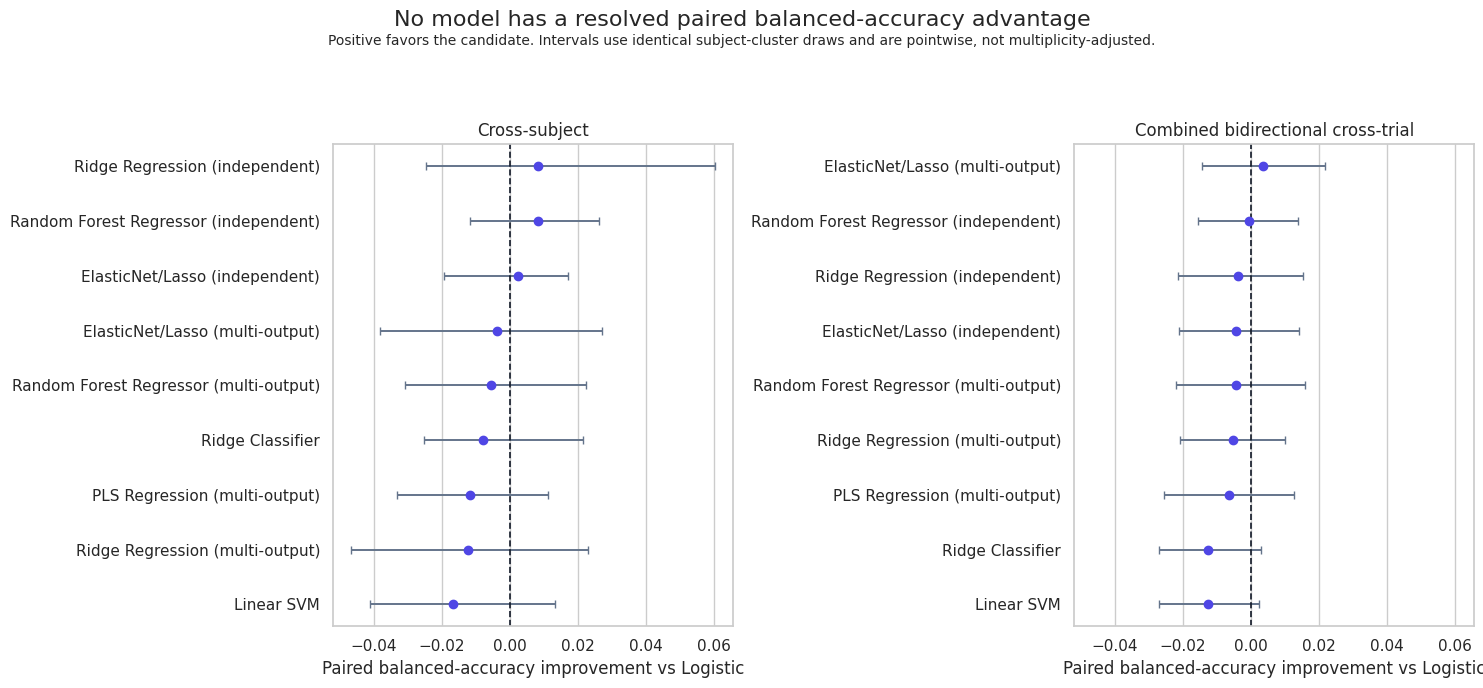

In [6]:
ba_paired = paired_df.loc[
    (paired_df["metric"] == "mean_balanced_accuracy")
    & (paired_df["model_id"] != "logistic-regression-independent")
]
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True)
for ax, protocol_label in zip(axes, PROTOCOL_LABELS.values(), strict=True):
    frame = (
        ba_paired.loc[ba_paired["protocol"] == protocol_label]
        .sort_values("improvement")
        .reset_index(drop=True)
    )
    y = np.arange(len(frame))
    ax.errorbar(
        frame["improvement"],
        y,
        xerr=np.vstack(
            [
                frame["improvement"] - frame["ci_low"],
                frame["ci_high"] - frame["improvement"],
            ]
        ),
        fmt="o",
        color="#4f46e5",
        ecolor="#64748b",
        elinewidth=1.4,
        capsize=3,
    )
    ax.axvline(0.0, color="#111827", linestyle="--", linewidth=1.2)
    ax.set_yticks(y, frame["model"])
    ax.set_title(protocol_label)
    ax.set_xlabel("Paired balanced-accuracy improvement vs Logistic")
    ax.grid(axis="y", visible=False)
fig.suptitle("No model has a resolved paired balanced-accuracy advantage", fontsize=16)
fig.text(
    0.5,
    0.93,
    "Positive favors the candidate. Intervals use identical subject-cluster draws and are "
    "pointwise, not multiplicity-adjusted.",
    ha="center",
    fontsize=10,
)
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

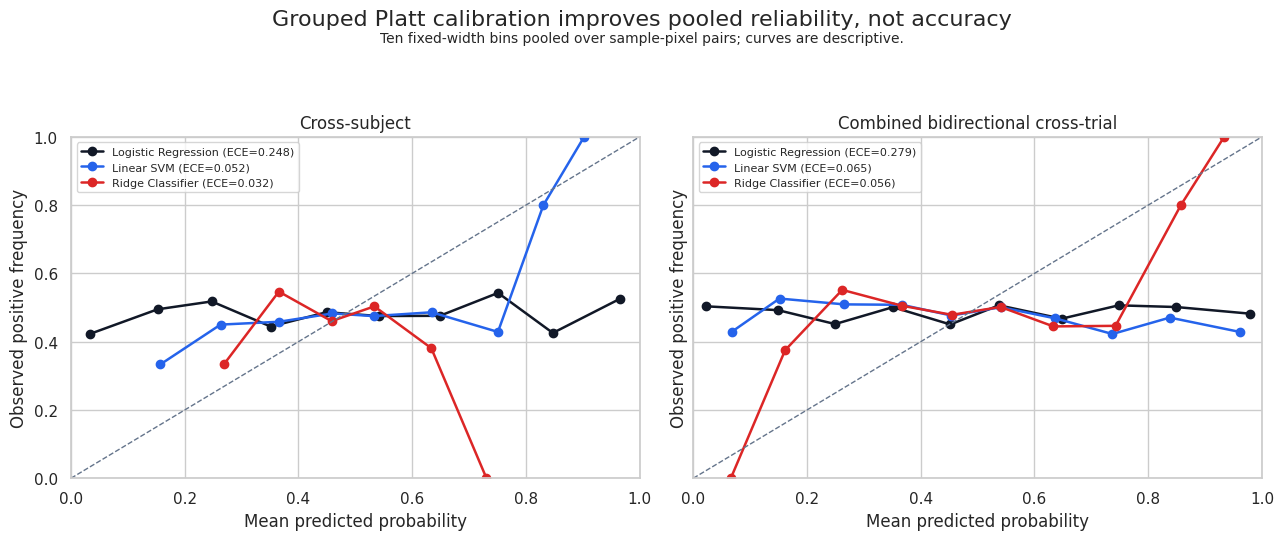

In [7]:
classifier_palette = {
    "logistic-regression-independent": "#111827",
    "linear-svm-independent": "#2563eb",
    "ridge-classifier-independent": "#dc2626",
}
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, (protocol, comparison) in zip(axes, comparisons.items(), strict=True):
    for model in comparison.models:
        if not model.calibration_bins:
            continue
        ax.plot(
            [item.mean_score for item in model.calibration_bins],
            [item.observed_frequency for item in model.calibration_bins],
            marker="o",
            linewidth=1.8,
            color=classifier_palette[model.model_id],
            label=f"{model.label} (ECE={model.calibration_ece:.3f})",
        )
    ax.plot([0, 1], [0, 1], linestyle="--", color="#64748b", linewidth=1)
    ax.set_title(PROTOCOL_LABELS[protocol])
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed positive frequency")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc="best")
fig.suptitle("Grouped Platt calibration improves pooled reliability, not accuracy", fontsize=16)
fig.text(
    0.5,
    0.92,
    "Ten fixed-width bins pooled over sample-pixel pairs; curves are descriptive.",
    ha="center",
    fontsize=10,
)
fig.tight_layout(rect=(0, 0, 1, 0.89))
plt.show()

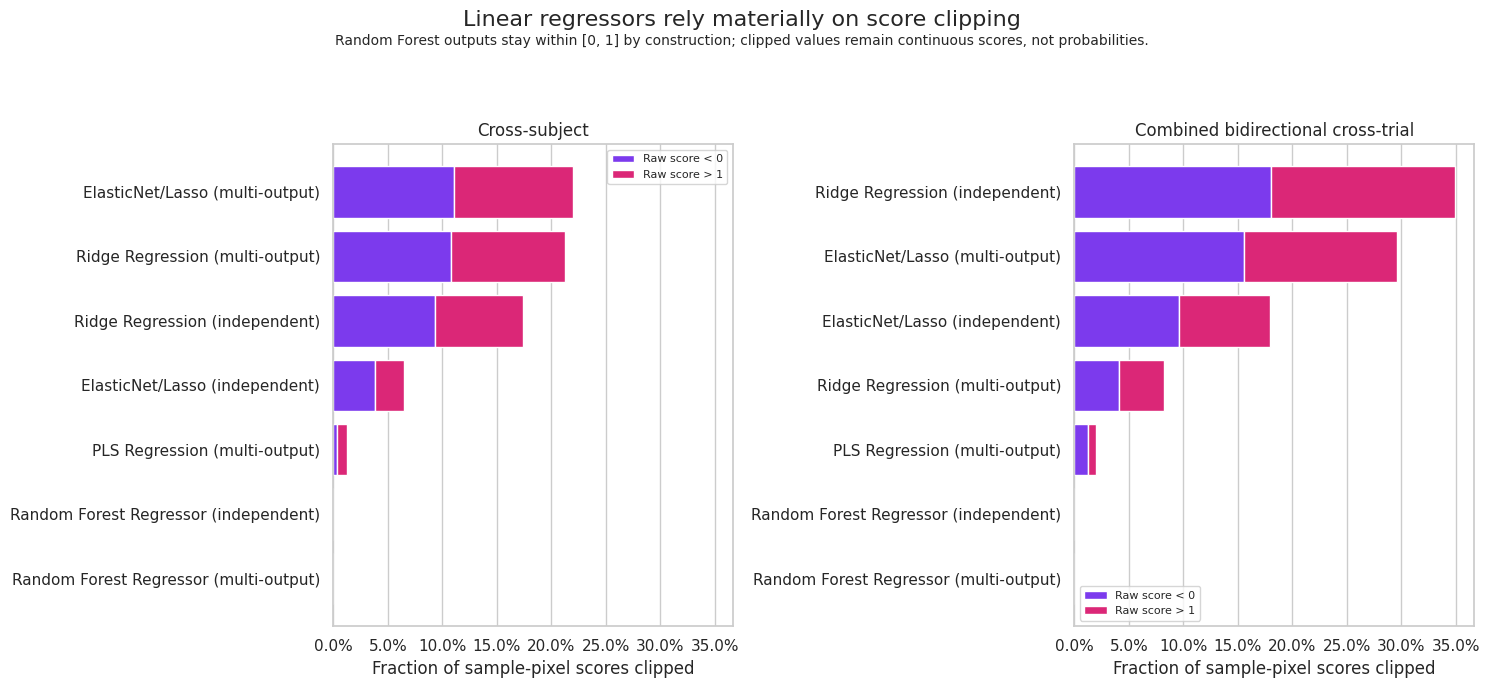

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True)
for ax, protocol_label in zip(axes, PROTOCOL_LABELS.values(), strict=True):
    frame = (
        clipping_df.loc[clipping_df["protocol"] == protocol_label]
        .sort_values("total_clipped")
        .reset_index(drop=True)
    )
    y = np.arange(len(frame))
    ax.barh(y, frame["below_zero"], color="#7c3aed", label="Raw score < 0")
    ax.barh(
        y,
        frame["above_one"],
        left=frame["below_zero"],
        color="#db2777",
        label="Raw score > 1",
    )
    ax.set_yticks(y, frame["model"])
    ax.set_title(protocol_label)
    ax.set_xlabel("Fraction of sample-pixel scores clipped")
    ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
    ax.grid(axis="y", visible=False)
    ax.legend(fontsize=8)
fig.suptitle("Linear regressors rely materially on score clipping", fontsize=16)
fig.text(
    0.5,
    0.93,
    "Random Forest outputs stay within [0, 1] by construction; clipped values remain "
    "continuous scores, not probabilities.",
    ha="center",
    fontsize=10,
)
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

In [9]:
metric_labels = {
    "mean_balanced_accuracy": "Balanced accuracy",
    "mean_score_mse": "Score-MSE",
    "mean_sample_iou": "Sample IoU",
    "hamming_loss": "Hamming loss",
}
paired_display = paired_df.loc[
    paired_df["model_id"] != "logistic-regression-independent"
].copy()
paired_display["metric"] = paired_display["metric"].map(metric_labels)
display(
    paired_display.sort_values(["protocol", "metric", "improvement"], ascending=[True, True, False])
    .drop(columns=["model_id"])
    .style.format(
        {"improvement": "{:+.3f}", "ci_low": "{:+.3f}", "ci_high": "{:+.3f}"}
    )
)

,protocol,model,metric,improvement,ci_low,ci_high
64,Combined bidirectional cross-trial,ElasticNet/Lasso (multi-output),Balanced accuracy,+0.003,-0.014,+0.022
68,Combined bidirectional cross-trial,Random Forest Regressor (independent),Balanced accuracy,-0.001,-0.015,+0.014
52,Combined bidirectional cross-trial,Ridge Regression (independent),Balanced accuracy,-0.004,-0.021,+0.015
60,Combined bidirectional cross-trial,ElasticNet/Lasso (independent),Balanced accuracy,-0.004,-0.021,+0.014
72,Combined bidirectional cross-trial,Random Forest Regressor (multi-output),Balanced accuracy,-0.004,-0.022,+0.016
56,Combined bidirectional cross-trial,Ridge Regression (multi-output),Balanced accuracy,-0.005,-0.021,+0.010
76,Combined bidirectional cross-trial,PLS Regression (multi-output),Balanced accuracy,-0.006,-0.025,+0.013
48,Combined bidirectional cross-trial,Ridge Classifier,Balanced accuracy,-0.013,-0.027,+0.003
44,Combined bidirectional cross-trial,Linear SVM,Balanced accuracy,-0.013,-0.027,+0.002
67,Combined bidirectional cross-trial,ElasticNet/Lasso (multi-output),Hamming loss,+0.003,-0.015,+0.022


## Takeaways

1. **The EEG feature/model combinations do not support above-chance reconstruction claims.**
   Cross-subject and combined cross-trial balanced accuracy stay tightly around 0.5, and no
   candidate has a paired balanced-accuracy interval excluding zero versus Logistic Regression.
2. **Descriptive model ranks are unstable and protocol-specific.** Independent Ridge Regression
   and Random Forest lead cross-subject at about 0.518, while multi-output ElasticNet/Lasso leads
   within-subject at 0.503. Averaging these protocols would erase their different scientific
   meanings and is not done.
3. **Calibration and discrimination separate cleanly.** SVM and Ridge Classifier reduce pooled
   ECE from 0.248 to 0.052/0.032 cross-subject and from 0.279 to 0.065/0.056 within-subject, yet
   their balanced accuracy remains at or below chance. Better-behaved probabilities do not create
   predictive signal.
4. **Score-MSE does not rescue the learned models.** The global-majority baseline records 0.250
   score-MSE in both protocols, lower than every learned model. Metric semantics also differ:
   classifier values are probability Brier scores, whereas regressor values are clipped-output
   MSE.
5. **Clipping is a substantive regression diagnostic.** Within-subject independent Ridge clips
   about 35% of raw sample-pixel outputs and multi-output ElasticNet about 30%; Random Forest clips
   none. These outputs should not be interpreted as calibrated probabilities.

PLS remains exploratory. All intervals in this notebook are pointwise and unadjusted for the
multiple model/metric comparisons, so isolated descriptive differences should not be promoted to
confirmatory claims.

In [10]:
assert len(models_df) == 20
assert len(baselines_df) == 6
assert set(models_df["exact_match"]) == {0.0}
assert all(
    row.ci_low <= 0.0 <= row.ci_high
    for row in ba_paired.itertuples(index=False)
)
assert all(
    calibration_df.loc[
        calibration_df["model_id"] != "logistic-regression-independent", "ece"
    ].to_numpy()
    < calibration_df.loc[
        calibration_df["model_id"] == "logistic-regression-independent", "ece"
    ].max()
)
print("CLASSICAL_MODELS_COMPARISON_VERIFIED")

CLASSICAL_MODELS_COMPARISON_VERIFIED
